In [3]:
!pip install -q kaggle tensorflow opencv-python

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gamrutharaju","key":"b40678cda2c56784fb3bc1fa73aef9ab"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [01:42<00:00, 22.4MB/s]



In [6]:
import zipfile

with zipfile.ZipFile("leapgestrecog.zip","r") as zip_ref:
    zip_ref.extractall("dataset")

In [7]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

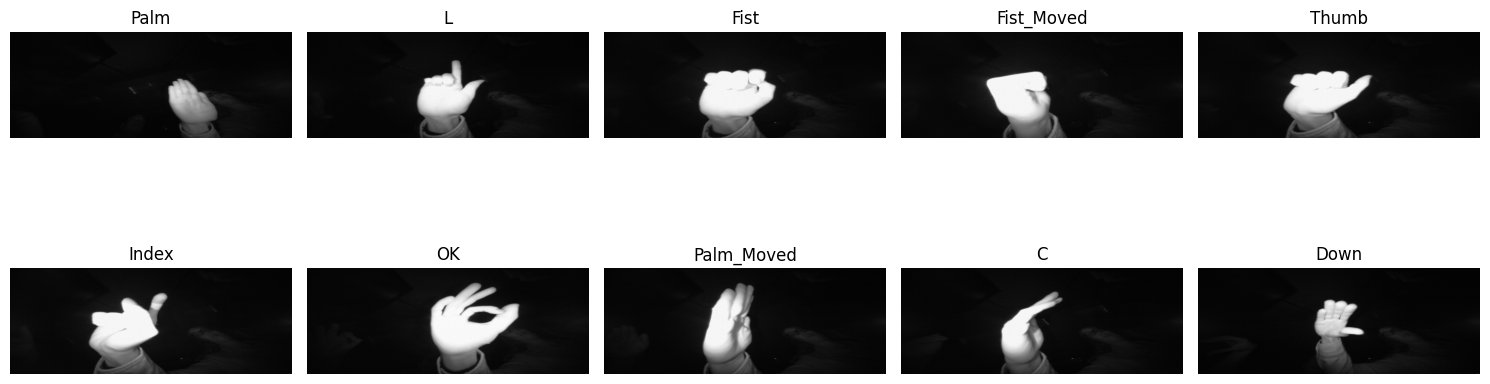

In [8]:
data = []
labels = []

dataset_path = "dataset/leapGestRecog"

gesture_names = [
    "Palm",
    "L",
    "Fist",
    "Fist_Moved",
    "Thumb",
    "Index",
    "OK",
    "Palm_Moved",
    "C",
    "Down"
]

image_size = 64

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for gesture_folder in os.listdir(person_path):

        folder_path = os.path.join(person_path, gesture_folder)

        label = int(gesture_folder[:2]) - 1

        for image_name in os.listdir(folder_path):

            image_path = os.path.join(folder_path, image_name)

            image = cv2.imread(image_path)

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            image = cv2.resize(image, (image_size,image_size))

            data.append(image)

            labels.append(label)

#Dataset
dataset_path = "dataset/leapGestRecog"

gesture_names = [
    "Palm", "L", "Fist", "Fist_Moved", "Thumb",
    "Index", "OK", "Palm_Moved", "C", "Down"
]

# Use the first person's folder
person = sorted(os.listdir(dataset_path))[0]
person_path = os.path.join(dataset_path, person)

gesture_folders = sorted(os.listdir(person_path))

plt.figure(figsize=(15, 6))

for i, folder in enumerate(gesture_folders):
    folder_path = os.path.join(person_path, folder)
    image_name = sorted(os.listdir(folder_path))[0]

    image = cv2.imread(os.path.join(folder_path, image_name))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(gesture_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
X = np.array(data,dtype="float32")/255.0

y = np.array(labels)

print("Images :",X.shape)

print("Labels :",y.shape)

Images : (20000, 64, 64, 3)
Labels : (20000,)


In [10]:
print("Unique labels:", np.unique(y))
print("Min label:", np.min(y))
print("Max label:", np.max(y))

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Min label: 0
Max label: 9


In [11]:
for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)
    if os.path.isdir(person_path):
        print(sorted(os.listdir(person_path)))
        break

['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [12]:
y = to_categorical(y,10)

In [13]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [14]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.3))

model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 87s 211ms/step - accuracy: 0.8914 - loss: 0.3232 - val_accuracy: 0.9969 - val_loss: 0.0130
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 85s 213ms/step - accuracy: 0.9940 - loss: 0.0183 - val_accuracy: 0.9978 - val_loss: 0.0065
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 143s 217ms/step - accuracy: 0.9943 - loss: 0.0184 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 140s 213ms/step - accuracy: 0.9978 - loss: 0.0096 - val_accuracy: 0.9937 - val_loss: 0.0139
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 146s 223ms/step - accuracy: 0.9972 - loss: 0.0084 - val_accuracy: 0.9987 - val_loss: 0.0026
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 205ms/step - accuracy: 0.9973 - loss: 0.0087 - val_accuracy: 0.9994 - val_loss: 0.0024
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 84s 210ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9987 - val_loss: 0.0028
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 91s 227ms/step - accuracy: 0.9986 - loss

In [17]:
loss,accuracy=model.evaluate(X_test,y_test)

print(f"\nTest Accuracy : {accuracy*100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9987 - loss: 0.0020

Test Accuracy : 99.87%


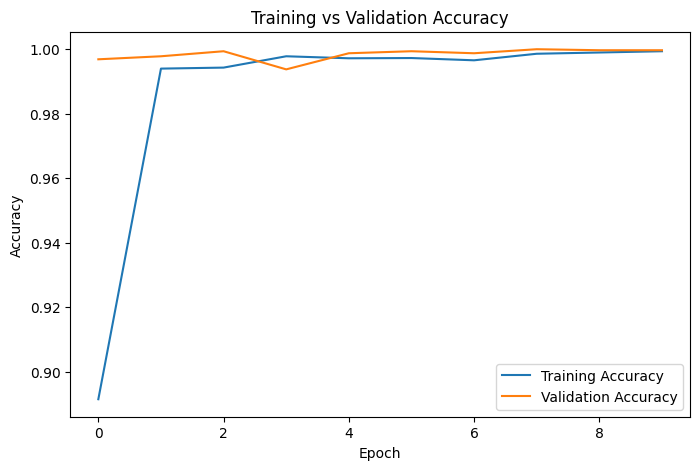

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

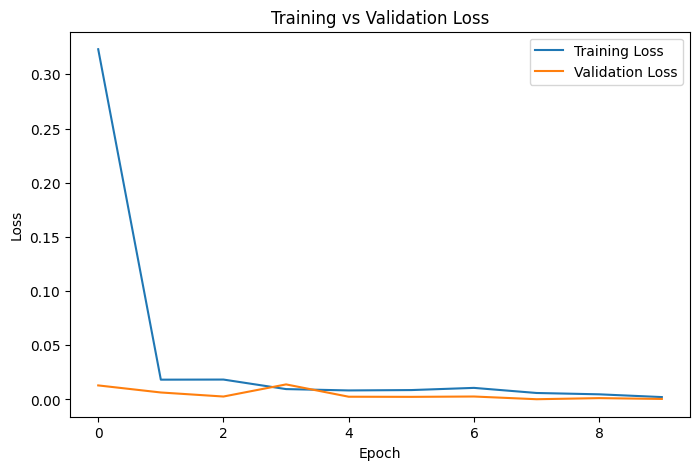

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

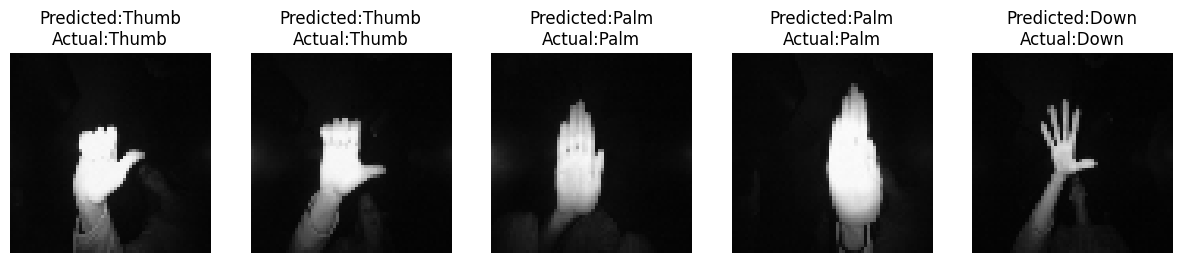

In [20]:
indices = random.sample(range(len(X_test)),5)

plt.figure(figsize=(15,4))

for i,index in enumerate(indices):

    prediction = model.predict(X_test[index].reshape(1,64,64,3),verbose=0)

    predicted = np.argmax(prediction)

    actual = np.argmax(y_test[index])

    plt.subplot(1,5,i+1)

    plt.imshow(X_test[index])

    plt.title(f"Predicted:{gesture_names[predicted]}\nActual:{gesture_names[actual]}")

    plt.axis("off")

plt.show()

In [21]:
model.save("hand_gesture_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
